In [19]:
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix

assert tf.__version__.startswith('2'), f'TF 2.x required, got {tf.__version__}'
print(f'TensorFlow: {tf.__version__}')
print(f'GPUs available: {tf.config.list_physical_devices("GPU")}')


TensorFlow: 2.21.0
GPUs available: []


In [20]:
# ── Data paths ───────────────────────────────────────────────────────────────
TRAIN_PKL        = '../data/folds-w-meta.pkl'   # pickle with train folds
TEST_PKL         = '../data/test-w-meta.pkl'     # pickle with test fold
FOLDER_IMAGE_DIR = '../data/classes/'            # optional extra labelled images

# ── Image / training hyper-parameters ────────────────────────────────────────
CLASSIFY_IMAGE_SIZE   = (75, 200)   # native resolution in the pkl files
ESTIMATE_IMAGE_SIZE   = (224, 224)  # EfficientNetB0 expects 224x224
BATCH_SIZE            = 32
CLASSIFIER_EPOCHS     = 10
ESTIMATOR_EPOCHS      = 10

# ── Size-bin definitions ──────────────────────────────────────────────────────
# Upper bound in mm → label string (used as folder names too)

### Updated bin edges and labels to include more bins for better resolution
BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 450, 500, 550, 600, 650, 700, 800, 900]
BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '45', '50', '55', '60', '65', '70', '80', '90']

### Original Bin edges and labels (edges in mm, labels in cm)
#BIN_EDGES  = [100, 150, 200, 250, 300, 350, 400, 500, 600, 700]
#BIN_LABELS = [ '10', '15', '20', '25', '30', '35', '40', '50', '60', '70']
NUM_SIZE_BINS = len(BIN_LABELS)

def length_to_bin(length_mm):
    """Map a length in mm to a size-bin index. Returns None if out of range."""
    for i, edge in enumerate(BIN_EDGES):
        if length_mm <= edge:
            return i
    return None


In [21]:
def load_pkl(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='latin1')  # latin1 handles Python-2-saved pkls

train_folds = load_pkl(TRAIN_PKL)
test_folds  = load_pkl(TEST_PKL)

print(f'Train folds: {len(train_folds)}')
print(f'Keys per fold: {list(train_folds[0].keys())}')
print(f'Images in fold 0: {train_folds[0]["data"].shape}')


Train folds: 10
Keys per fold: ['fold', 'length', 'weight', 'source', 'girth', 'data', 'id', 'class']
Images in fold 0: (63, 9, 75, 200, 3)


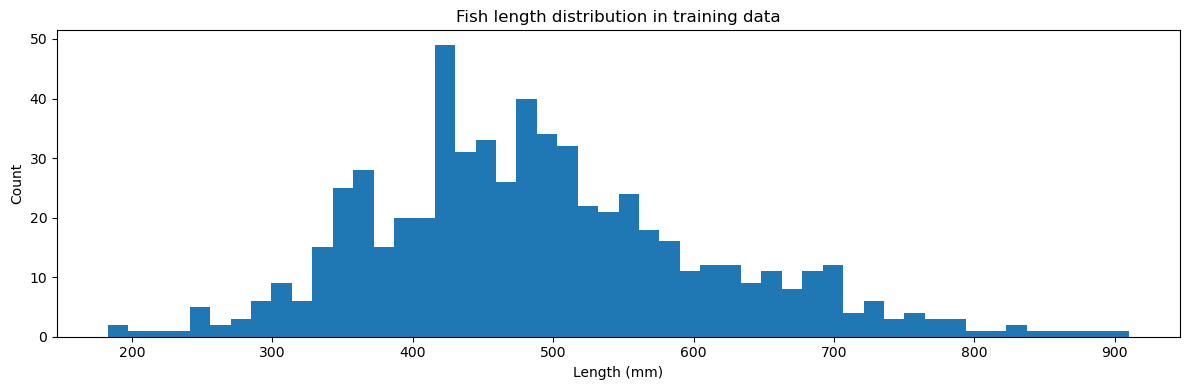

Min: 183mm, Max: 910mm, N: 623


In [22]:
all_lengths = []
for fold in train_folds:
    for length in fold['length']:
        if length is None or str(length).strip() in ('', 'NA'): continue
        all_lengths.append(float(length))

plt.figure(figsize=(12, 4))
plt.hist(all_lengths, bins=50)
plt.xlabel('Length (mm)'); plt.ylabel('Count')
plt.title('Fish length distribution in training data')
plt.tight_layout(); plt.show()

print(f'Min: {min(all_lengths):.0f}mm, Max: {max(all_lengths):.0f}mm, N: {len(all_lengths)}')

# Classification

In [23]:
TRAIN_FOLDS = list(range(0, 8))
VAL_FOLD    = 8
TEST_FOLD   = 9

def load_classification_folds(fold_indices, metadata, label_key='class'):
    """Unpack fold dicts into flat (N*9, 75, 200, 3) image arrays."""
    X_list, y_list = [], []
    for i in fold_indices:
        X = metadata[i]['data']       # (N, 9, 75, 200, 3) — 9 views per fish
        y = metadata[i][label_key]    # (N,)
        X = X.reshape(-1, 75, 200, 3)
        y = np.repeat(y, 9)
        X_list.append(X)
        y_list.append(y)
    return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)

X_cls_train, y_cls_train = load_classification_folds(TRAIN_FOLDS, train_folds)
X_cls_val,   y_cls_val   = load_classification_folds([VAL_FOLD],  train_folds)
X_cls_test,  y_cls_test  = load_classification_folds([TEST_FOLD], train_folds)

print(f'Train: {X_cls_train.shape}, Val: {X_cls_val.shape}, Test: {X_cls_test.shape}')

# Normalise
X_cls_train = X_cls_train.astype('float32') / 255.0
X_cls_val   = X_cls_val.astype('float32')   / 255.0
X_cls_test  = X_cls_test.astype('float32')  / 255.0

# Encode string species labels → integers
species_le = LabelEncoder()
species_le.fit(np.concatenate([y_cls_train, y_cls_val, y_cls_test]))
y_cls_train_enc = species_le.transform(y_cls_train)
y_cls_val_enc   = species_le.transform(y_cls_val)
y_cls_test_enc  = species_le.transform(y_cls_test)
NUM_SPECIES = len(species_le.classes_)

print(f'Species ({NUM_SPECIES}): {species_le.classes_}')


Train: (4491, 75, 200, 3), Val: (558, 75, 200, 3), Test: (558, 75, 200, 3)
Species (22): ['BHC' 'BUF' 'CC' 'CCF' 'CWS' 'FWD' 'GC' 'GF' 'GS' 'LNG' 'LNS' 'NHS' 'NP'
 'QBS' 'RHS' 'RRS' 'SC' 'SL' 'SMB' 'WB' 'WP' 'WYE']


In [24]:
def residual_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding='same')(shortcut)
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

def build_classifier(num_classes, input_shape=(75, 200, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 32)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 64)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

classifier = build_classifier(NUM_SPECIES)
classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
classifier.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 75, 200,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 75, 200,   │        896 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 75, 200,   │        128 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 37, 100,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 37, 100,   │      9,248 │ max_pooling2d_3[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_10[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 37, 100,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 37, 100,   │        128 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 37, 100,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 37, 100,   │          0 │ add_3[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 18, 50,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 18, 50,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 18, 50,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 18, 50,    │        256 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 18, 50,    │      2,112 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 18, 50,    │          0 │ batch_normalizat

 Total params: 318,294 (1.21 MB)

 Trainable params: 317,334 (1.21 MB)

 Non-trainable params: 960 (3.75 KB)

## Train Classifier

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - accuracy: 0.6039 - loss: 1.4107 - val_accuracy: 0.0968 - val_loss: 3.2270
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 20s 140ms/step - accuracy: 0.7845 - loss: 0.7652 - val_accuracy: 0.0950 - val_loss: 4.0120
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 137ms/step - accuracy: 0.8479 - loss: 0.5360 - val_accuracy: 0.0645 - val_loss: 6.8920
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.8711 - loss: 0.4457 - val_accuracy: 0.4247 - val_loss: 2.4270
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.8980 - loss: 0.3383 - val_accuracy: 0.0627 - val_loss: 11.6606
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 138ms/step - accuracy: 0.9105 - loss: 0.2988 - val_accuracy: 0.2939 - val_loss: 11.3084
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 136ms/step - accuracy: 0.9141 - loss: 0.2745 - val_accuracy: 0.3692 - val_loss: 5.2245


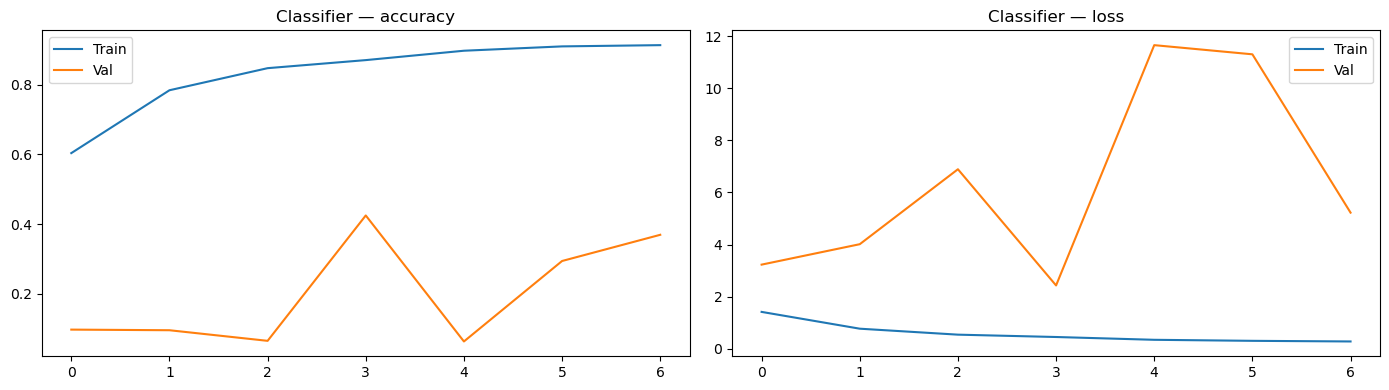

Classifier test accuracy: 37.10%


In [25]:
early_stop_cls = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

cls_history = classifier.fit(
    X_cls_train, y_cls_train_enc,
    validation_data=(X_cls_val, y_cls_val_enc),
    epochs=CLASSIFIER_EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop_cls]
)

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(cls_history.history['accuracy'],     label='Train')
ax1.plot(cls_history.history['val_accuracy'], label='Val')
ax1.set_title('Classifier — accuracy'); ax1.legend()
ax2.plot(cls_history.history['loss'],     label='Train')
ax2.plot(cls_history.history['val_loss'], label='Val')
ax2.set_title('Classifier — loss'); ax2.legend()
plt.tight_layout(); plt.show()

test_loss, test_acc = classifier.evaluate(X_cls_test, y_cls_test_enc, verbose=0)
print(f'Classifier test accuracy: {test_acc:.2%}')


# Size Estimator

Loading train/val folds...
Loaded 622, skipped 1
Loading test fold...
Loaded 71, skipped 0
Loading folder images...
Folder images loaded: 202, skipped: 0

Train: 659  Val: 165  Test: 71


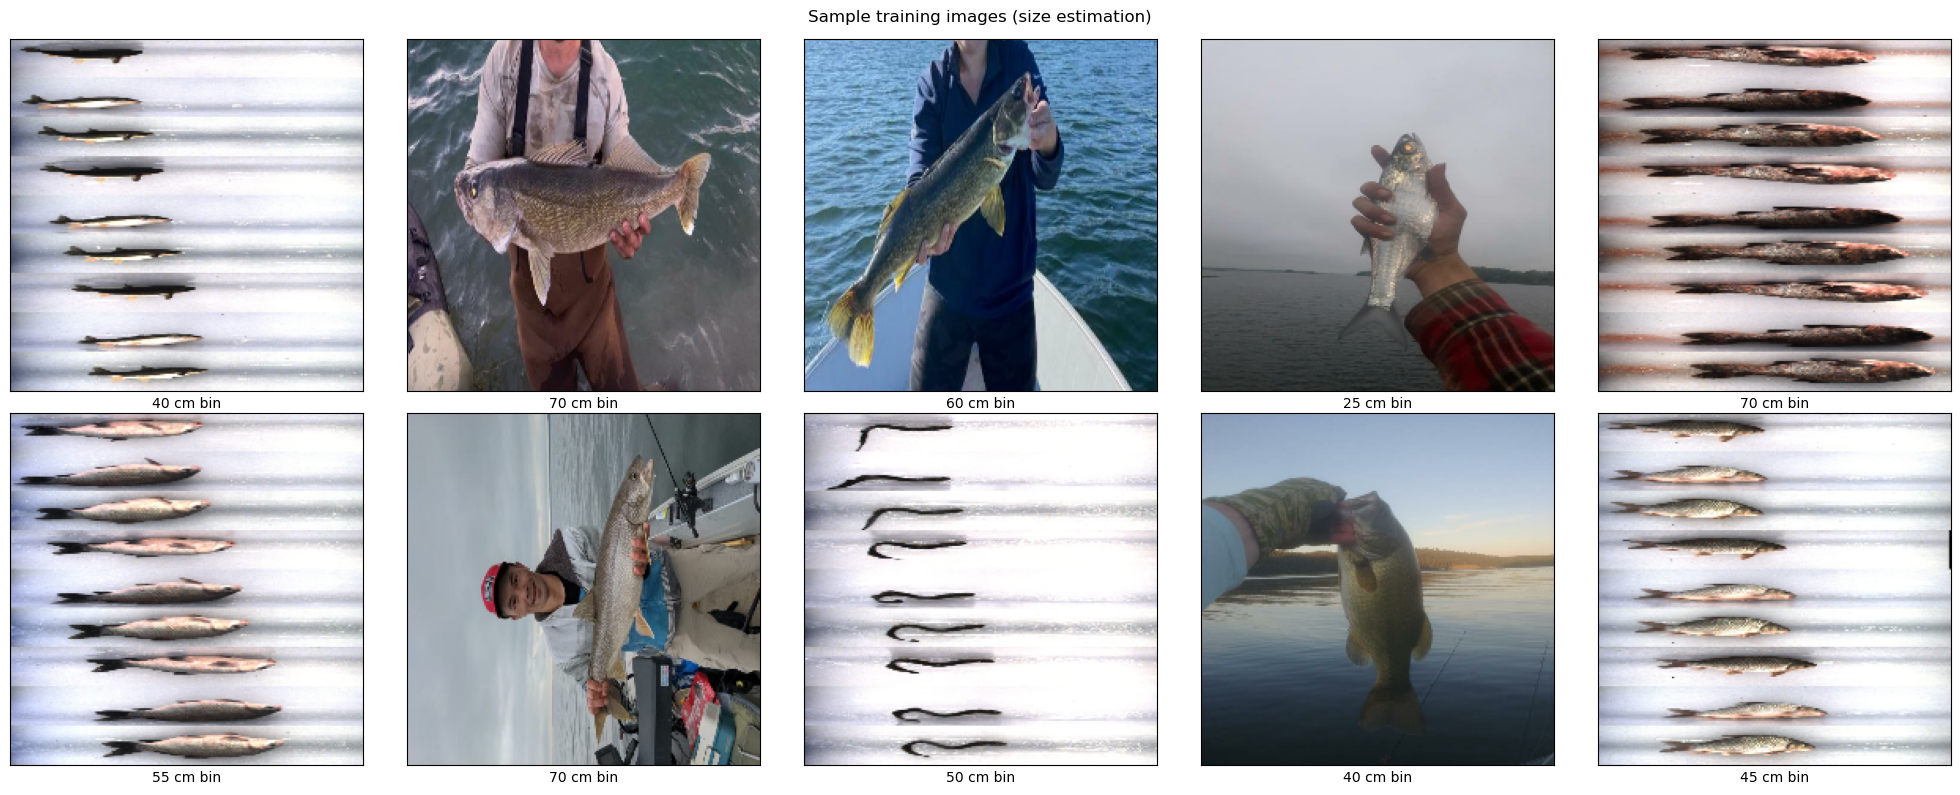

In [26]:
AUTOTUNE = tf.data.AUTOTUNE

def folds_to_arrays_for_estimation(folds):
    """Convert pkl folds to (N, 224, 224, 3) float32 images and size-bin labels."""
    X, y = [], []
    skipped = 0
    for fold in folds:
        for i, raw in enumerate(fold['data']):
            length = fold['length'][i]
            if length is None or str(length).strip() in ('', 'NA'):
                skipped += 1; continue
            bin_idx = length_to_bin(float(length))
            if bin_idx is None:
                skipped += 1; continue
            img = np.reshape(raw, (-1, 200, 3)).astype(np.float32)
            img_resized = tf.image.resize(img, ESTIMATE_IMAGE_SIZE).numpy()
            X.append(img_resized)
            y.append(bin_idx)
    print(f'Loaded {len(X)}, skipped {skipped}')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

def load_folder_images(root_dir):
    """Load folder-organised images (root/BIN_LABEL/image.jpg)."""
    if not os.path.isdir(root_dir):
        print(f'Folder image directory not found ({root_dir}), skipping.')
        return np.empty((0, *ESTIMATE_IMAGE_SIZE, 3), dtype=np.float32), np.empty((0,), dtype=np.int32)
    label_to_idx = {label: i for i, label in enumerate(BIN_LABELS)}
    X, y, skipped = [], [], 0
    for folder_name in sorted(os.listdir(root_dir)):
        folder_path = os.path.join(root_dir, folder_name)
        if not os.path.isdir(folder_path): continue
        bin_key = folder_name.lower().replace('class', '').strip()
        if bin_key not in label_to_idx:
            print(f'  Skipping unrecognised folder: {folder_name}'); continue
        bin_idx = label_to_idx[bin_key]
        for fname in os.listdir(folder_path):
            fpath = os.path.join(folder_path, fname)
            try:
                raw = tf.io.read_file(fpath)
                img = tf.image.decode_image(raw, channels=3, expand_animations=False)
                img = tf.image.resize(img, ESTIMATE_IMAGE_SIZE)
                X.append(img.numpy().astype(np.float32))
                y.append(bin_idx)
            except Exception as e:
                print(f'  Could not load {fpath}: {e}'); skipped += 1
    print(f'Folder images loaded: {len(X)}, skipped: {skipped}')
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.int32)

print('Loading train/val folds...')
X_est_pkl, y_est_pkl = folds_to_arrays_for_estimation(train_folds)
print('Loading test fold...')
X_est_test, y_est_test = folds_to_arrays_for_estimation(test_folds)
print('Loading folder images...')
X_folder, y_folder = load_folder_images(FOLDER_IMAGE_DIR)

X_est_all = np.concatenate([X_est_pkl, X_folder], axis=0)
y_est_all = np.concatenate([y_est_pkl, y_folder], axis=0)

X_est_train, X_est_val, y_est_train, y_est_val = train_test_split(
    X_est_all, y_est_all, test_size=0.2, random_state=42, stratify=y_est_all
)
print(f'\nTrain: {X_est_train.shape[0]}  Val: {X_est_val.shape[0]}  Test: {X_est_test.shape[0]}')

est_train_ds = (tf.data.Dataset.from_tensor_slices((X_est_train, y_est_train))
                .shuffle(len(X_est_train), seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE))
est_val_ds   = (tf.data.Dataset.from_tensor_slices((X_est_val, y_est_val))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))
est_test_ds  = (tf.data.Dataset.from_tensor_slices((X_est_test, y_est_test))
                .batch(BATCH_SIZE).prefetch(AUTOTUNE))

# Preview
plt.figure(figsize=(20, 8))
sample_imgs, sample_lbls = next(iter(
    tf.data.Dataset.from_tensor_slices((X_est_train, y_est_train)).batch(10)
))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(sample_imgs[i].numpy().astype('uint8'))
    plt.xlabel(f'{BIN_LABELS[sample_lbls[i]]} cm bin')
plt.suptitle('Sample training images (size estimation)')
plt.tight_layout(); plt.show()


In [27]:
def build_estimator(num_classes):
    base = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=ESTIMATE_IMAGE_SIZE + (3,),
        pooling='avg'
    )
    base.trainable = False  # fine-tune in a later stage if desired
    model = tf.keras.Sequential([
        base,
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

estimator = build_estimator(NUM_SIZE_BINS)
estimator.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,068,786 (15.52 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## Train Model

Epoch 1/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 321ms/step - accuracy: 0.1335 - loss: 2.4956 - val_accuracy: 0.1576 - val_loss: 2.2903
Epoch 2/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step - accuracy: 0.2519 - loss: 1.9891 - val_accuracy: 0.2545 - val_loss: 2.0575
Epoch 3/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.3096 - loss: 1.7553 - val_accuracy: 0.2424 - val_loss: 1.9887
Epoch 4/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.3520 - loss: 1.6146 - val_accuracy: 0.3030 - val_loss: 1.8990
Epoch 5/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.3945 - loss: 1.4775 - val_accuracy: 0.3212 - val_loss: 1.8347
Epoch 6/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.4568 - loss: 1.3403 - val_accuracy: 0.3273 - val_loss: 1.7966
Epoch 7/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.4613 - loss: 1.2874 - val_accuracy: 0.3515 - val_loss: 1.7659
Epoch 8/10
21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 262ms/step - accuracy: 0.4932 - loss: 1.2823 - val_accuracy: 0

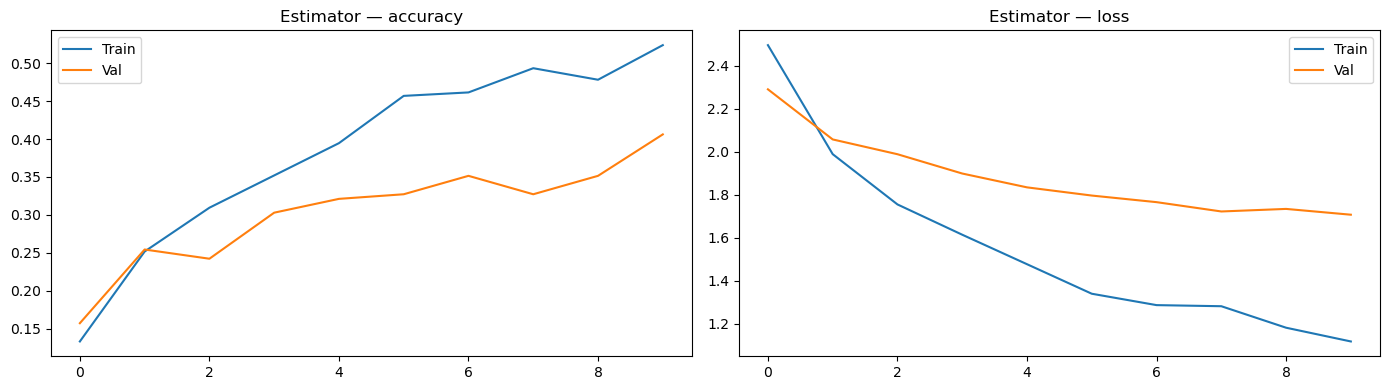

Train  — loss: 1.2783, accuracy: 57.97%
Val    — loss: 1.7076, accuracy: 40.61%
Test   — loss: 1.6649, accuracy: 39.44%


In [28]:
est_weights_arr = compute_class_weight('balanced', classes=np.unique(y_est_train), y=y_est_train)
est_class_weights = dict(enumerate(est_weights_arr))

early_stop_est = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

est_history = estimator.fit(
    est_train_ds,
    validation_data=est_val_ds,
    epochs=ESTIMATOR_EPOCHS,
    class_weight=est_class_weights,
    callbacks=[early_stop_est]
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
ax1.plot(est_history.history['accuracy'],     label='Train')
ax1.plot(est_history.history['val_accuracy'], label='Val')
ax1.set_title('Estimator — accuracy'); ax1.legend()
ax2.plot(est_history.history['loss'],     label='Train')
ax2.plot(est_history.history['val_loss'], label='Val')
ax2.set_title('Estimator — loss'); ax2.legend()
plt.tight_layout(); plt.show()

for ds, name in [(est_train_ds, 'Train'), (est_val_ds, 'Val'), (est_test_ds, 'Test')]:
    loss, acc = estimator.evaluate(ds, verbose=0)
    print(f'{name:<6} — loss: {loss:.4f}, accuracy: {acc:.2%}')


## Combined Inference

Blends the estimator's softmax output with the classifier's species-informed size distribution using a 50/50 split. The `alpha` parameter is a placeholder for the biological prior weighting — swap `uniform_prior` for the real prior table once it is available.

In [29]:
def predict_combined(images_224, images_75_200, alpha=0.5):
    """
    Predict size bins by blending the size estimator and species classifier outputs.

    Parameters
    ----------
    images_224    : (N, 224, 224, 3) float32 — input for the size estimator
    images_75_200 : (N,  75, 200, 3) float32 — input for the species classifier
    alpha         : float in [0, 1] — weight given to the classifier signal (0 = estimator only)

    Returns
    -------
    pred_bins : (N,) int array of predicted size-bin indices
    """
    # Size estimator: P(bin | image)
    est_probs = estimator.predict(images_224, verbose=0)          # (N, NUM_SIZE_BINS)

    # Classifier: P(species | image)
    species_probs = classifier.predict(images_75_200, verbose=0)  # (N, NUM_SPECIES)

    # Placeholder uniform species->size mapping (NUM_SPECIES, NUM_SIZE_BINS)
    # Replace this with the biological prior table once it is available.
    uniform_prior = np.full((NUM_SPECIES, NUM_SIZE_BINS), 1.0 / NUM_SIZE_BINS)
    prior_scores  = species_probs @ uniform_prior                 # (N, NUM_SIZE_BINS)

    combined  = alpha * est_probs + (1 - alpha) * prior_scores
    pred_bins = np.argmax(combined, axis=1)
    return pred_bins


# ── Build the 75x200 test set (needed by the classifier) ─────────────────────
# Note: reshape to (75, 200, 3) explicitly — (-1, 200, 3) would incorrectly
# collapse all rows across the batch into a single dimension.
X_test_75_list = []
X_est_test_list = []
y_est_test_list = []

for fold in test_folds:
    for i, raw in enumerate(fold['data']):
        length = fold['length'][i]
        if length is None or str(length).strip() in ('', 'NA'): continue
        bin_idx = length_to_bin(float(length))
        if bin_idx is None: continue

        # One 75x200 view (view 0) per fish for the classifier
        img_75 = np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32) / 255.0
        X_test_75_list.append(img_75)

        # One 224x224 image per fish for the estimator
        img_224 = tf.image.resize(
            np.reshape(raw, (9, 75, 200, 3))[0].astype(np.float32),
            ESTIMATE_IMAGE_SIZE
        ).numpy() / 255.0
        X_est_test_list.append(img_224)

        y_est_test_list.append(bin_idx)

X_test_75       = np.array(X_test_75_list,  dtype=np.float32)
X_est_test_norm = np.array(X_est_test_list, dtype=np.float32)
y_est_test_aligned = np.array(y_est_test_list, dtype=np.int32)

# ── Evaluate ──────────────────────────────────────────────────────────────────
pred_bins = predict_combined(X_est_test_norm, X_test_75, alpha=0.5)
combined_acc = np.mean(pred_bins == y_est_test)

baseline_preds = np.argmax(estimator.predict(est_test_ds, verbose=0), axis=1)
baseline_acc   = np.mean(baseline_preds == y_est_test)

print(f'Estimator alone:   {baseline_acc:.2%}')
print(f'Combined (50/50):  {combined_acc:.2%}')
print(f'Difference:        {combined_acc - baseline_acc:+.2%}')


Estimator alone:   39.44%
Combined (50/50):  12.68%
Difference:        -26.76%


### Confusion matrix — combined pipeline

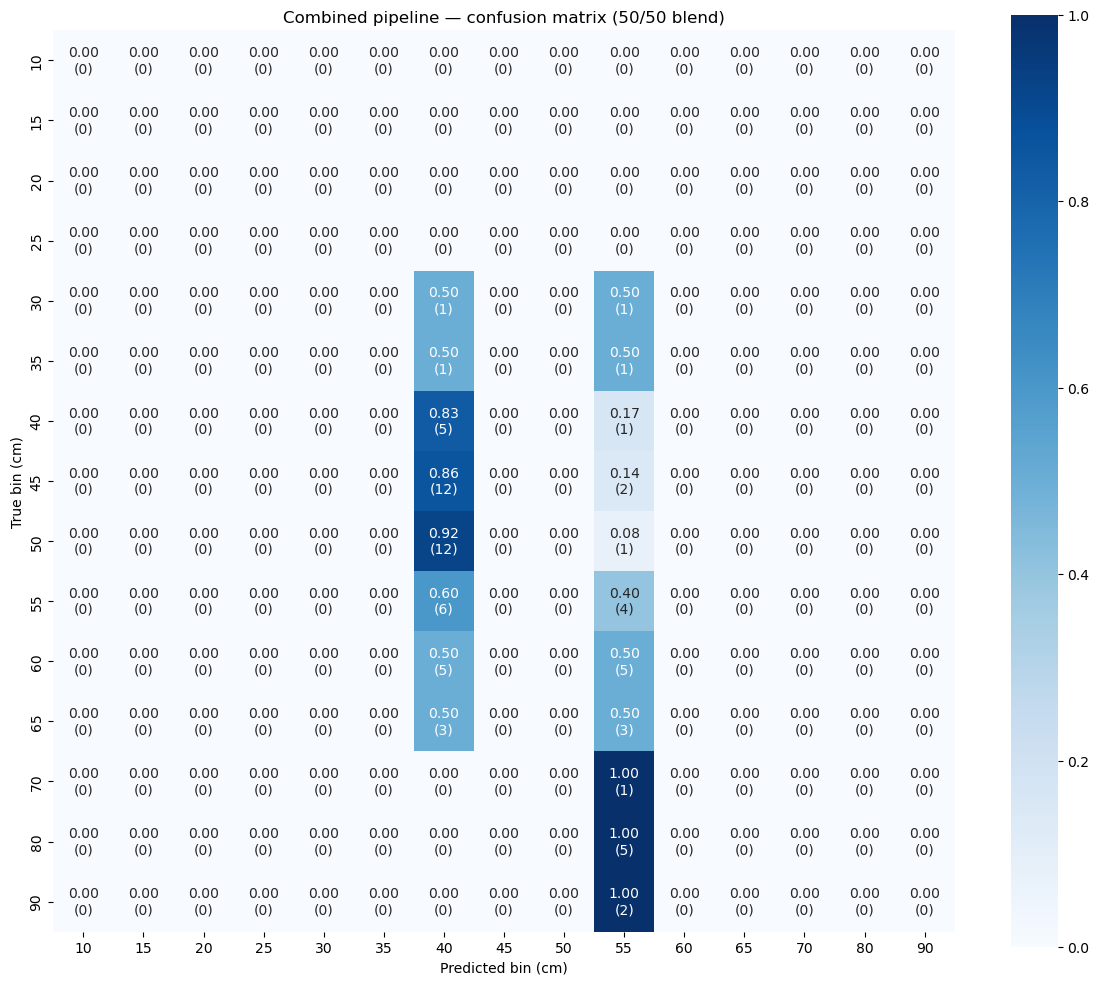

In [30]:
cm      = confusion_matrix(y_est_test, pred_bins, labels=list(range(NUM_SIZE_BINS)))
row_sum = cm.sum(axis=1, keepdims=True)
cm_norm = np.where(row_sum == 0, 0, cm.astype('float') / np.where(row_sum == 0, 1, row_sum))
annot   = np.array([[f'{cm_norm[i,j]:.2f}\n({cm[i,j]})' for j in range(NUM_SIZE_BINS)]
                     for i in range(NUM_SIZE_BINS)])

plt.figure(figsize=(12, 10))
sns.heatmap(cm_norm, xticklabels=BIN_LABELS, yticklabels=BIN_LABELS,
            cmap='Blues', annot=annot, fmt='', square=True, vmin=0, vmax=1)
plt.title('Combined pipeline — confusion matrix (50/50 blend)')
plt.ylabel('True bin (cm)'); plt.xlabel('Predicted bin (cm)')
plt.tight_layout(); plt.show()
